In [14]:
import sys
sys.path.append('src')

import warnings
warnings.filterwarnings("ignore")
import transformers
transformers.logging.set_verbosity_error()



Загрузка и подготовка данных

In [16]:
from data_utils import load_and_clean, split_data, build_vocab


import os
import pandas as pd

if os.path.exists("data/train.csv"):
    train_df = pd.read_csv("data/train.csv")
    val_df = pd.read_csv("data/val.csv")
    test_df = pd.read_csv("data/test.csv")
else:
    data = load_and_clean("data/raw_dataset.txt")
    train_df, val_df, test_df = split_data(data)
    train_df.to_csv("data/train.csv", index=False)
    val_df.to_csv("data/val.csv", index=False)
    test_df.to_csv("data/test.csv", index=False)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(train_df["text"].head(3))

Train: 1277468, Val: 159683, Test: 159684
0    ok time for the pub and some food i logged ko ...
1    it feels like strep throatbut i sure hope its ...
2                                   hand up in the air
Name: text, dtype: object


## Загрузка обученной LTSM

In [ ]:
import sys
sys.path.append("configs")

import torch
import json
from configs.config import *
from src.lstm_model import LSTMModel

# Загружаем словарь из файла, не пересчитываем
with open(VOCAB_PATH) as f:
    vocab = json.load(f)

vocab_size = len(vocab)

# Все параметры из конфига
model = LSTMModel(vocab_size, EMBEDDING_DIM, HIDDEN_SIZE, vocab_size, num_layers = NUM_LAYERS, dropout = DROPOUT)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
print(f"Модель загружена | vocab_size={vocab_size:,} | hidden={HIDDEN_SIZE}")


Модель загружена | vocab_size=112,359 | hidden=128


In [ ]:
# --- Покрытие vocab на val/test ---
all_val_words  = set(w for text in val_df["text"]  for w in text.split())
all_test_words = set(w for text in test_df["text"] for w in text.split())
vocab_words    = set(vocab.keys())

val_coverage  = len(all_val_words  & vocab_words) / len(all_val_words)  * 100
test_coverage = len(all_test_words & vocab_words) / len(all_test_words) * 100

unk_id = vocab.get("<unk>", None)

print(f"Размер словаря:          {len(vocab):,} слов")
print(f"Покрытие val:            {val_coverage:.1f}%")
print(f"Покрытие test:           {test_coverage:.1f}%")
print(f"Слов только в val:       {len(all_val_words - vocab_words):,}")
print(f"<UNK> token id:          {unk_id}")


Размер словаря:          112,359 слов
Покрытие val:            55.4%
Покрытие test:           55.3%
Слов только в val:       39,273
<UNK> token id:          None


In [8]:
# --- Архитектура модели ---
print(model)
print()

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb   = total_params * 4 / 1024**2  # float32 = 4 байта

print(f"Всего параметров:    {total_params:,}")
print(f"Обучаемых:           {trainable_params:,}")
print(f"Размер модели (MB):  {model_size_mb:.1f} МБ")


SimpleRNN(
  (embedding): Embedding(112359, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=112359, bias=True)
)

Всего параметров:    29,140,455
Обучаемых:           29,140,455
Размер модели (MB):  111.2 МБ


In [9]:
# --- Гиперпараметры ---
import pandas as pd

hparams = pd.DataFrame([
    {"Параметр": "embedding_dim",  "Значение": EMBEDDING_DIM,  "Описание": "Размерность эмбеддингов"},
    {"Параметр": "hidden_size",    "Значение": HIDDEN_SIZE,     "Описание": "Размер скрытого слоя LSTM"},
    {"Параметр": "num_layers",     "Значение": NUM_LAYERS,      "Описание": "Количество слоёв LSTM"},
    {"Параметр": "dropout",        "Значение": DROPOUT,         "Описание": "Dropout между слоями"},
    {"Параметр": "batch_size",     "Значение": 64,              "Описание": "Размер батча"},
    {"Параметр": "learning_rate",  "Значение": 0.001,           "Описание": "Adam lr"},
    {"Параметр": "n_epochs",       "Значение": 10,              "Описание": "Кол-во эпох обучения"},
    {"Параметр": "max_vocab_size", "Значение": MAX_VOCAB_SIZE,  "Описание": "Макс. размер словаря"},
])
print(hparams.to_string(index=False))


      Параметр  Значение                  Описание
 embedding_dim   128.000   Размерность эмбеддингов
   hidden_size   128.000 Размер скрытого слоя LSTM
    num_layers     2.000     Количество слоёв LSTM
       dropout     0.300      Dropout между слоями
    batch_size    64.000              Размер батча
 learning_rate     0.001                   Adam lr
      n_epochs    10.000      Кол-во эпох обучения
max_vocab_size       NaN      Макс. размер словаря


## Анализ кривых обучения

Смотрим на два признака здоровой модели:
- **Нет переобучения**: train_loss и val_loss должны идти вместе вниз
- **Сходимость**: ROUGE перестаёт расти — значит модель обучилась


In [11]:
# --- Автоматический анализ кривой обучения ---
import pandas as pd

df_log = pd.read_csv("training_log.csv")

best_epoch = df_log.loc[df_log["val_loss"].idxmin(), "epoch"]
best_val_loss = df_log["val_loss"].min()

# Проверка на расхождение train/val (переобучение)
df_log["gap"] = df_log["val_loss"] - df_log["train_loss"]
overfit_epoch = df_log[df_log["gap"] > 0.1]["epoch"]

print(f"Лучшая эпоха (min val_loss):  {best_epoch}")
print(f"Лучший val_loss:              {best_val_loss:.4f}")

if len(overfit_epoch) > 0:
    print(f"Признаки переобучения с эпохи: {overfit_epoch.iloc[0]}")
else:
    print("Признаков переобучения не обнаружено (gap < 0.1)")

print(f"\nПоследние 3 эпохи:")
print(df_log[["epoch","train_loss","val_loss","rouge1","rouge2"]].tail(3).to_string(index=False))


Лучшая эпоха (min val_loss):  10
Лучший val_loss:              2.2035
Признаков переобучения не обнаружено (gap < 0.1)

Последние 3 эпохи:
 epoch  train_loss  val_loss   rouge1   rouge2
     8    2.201935  2.207842 0.100255 0.011429
     9    2.194934  2.205209 0.110466 0.016262
    10    2.188383  2.203489 0.086036 0.011071


Подсчет ROUGE для LSTM

In [ ]:
from eval_lstm import evaluate_model

sample_texts = val_df["text"].tolist()
lstm_results = evaluate_model(model, sample_texts, vocab, max_samples=500)
print(f"LSTM ROUGE-1: {lstm_results['rouge1']:.4f}")
print(f"LSTM ROUGE-2: {lstm_results['rouge2']:.4f}")

LSTM ROUGE-1: 0.0858
LSTM ROUGE-2: 0.0112


Примеры предсказаний LTSM

In [ ]:
idx2word = {v: k for k, v in vocab.items()}

print("=== Примеры предсказаний LSTM ===\n")
for text in val_df["text"].tolist()[:5]:
    words = text.split()
    if len(words) < 4:
        continue
    cut = int(len(words) * 0.75)
    prefix_words = words[:cut]
    target_words = words[cut:]

    prefix_ids = [vocab.get(w, unk_id) for w in prefix_words]
    input_ids = torch.tensor([prefix_ids])
    lengths = torch.tensor([len(prefix_ids)])
    generated = model.generate(input_ids, lengths, max_new_tokens=5)
    new_tokens = generated[0][len(prefix_ids):]

    pred_text   = " ".join([idx2word.get(t.item(), "<unk>") for t in new_tokens])
    target_text = " ".join(target_words)

    print(f"Префикс:    {' '.join(prefix_words)}")
    print(f"Предсказан: {pred_text}")
    print(f"Таргет:     {target_text}")
    print()

=== Примеры предсказаний LSTM ===

Префикс:    now i dont wanna face
Предсказан: and i have to be
Таргет:     my dad

Префикс:    getting ready to drive to the other side of denver to go quotcry in our <unk> with
Предсказан: the day to be a
Таргет:     a friend who closed her lss

Префикс:    for once it
Предсказан: was a good i have
Таргет:     wasnt

Префикс:    crud sites down again trying to get it back up waiting for host to reply
Предсказан: to be a good i
Таргет:     we shall be launching soon

Префикс:    follow if your
Предсказан: i have to be a
Таргет:     an aussie



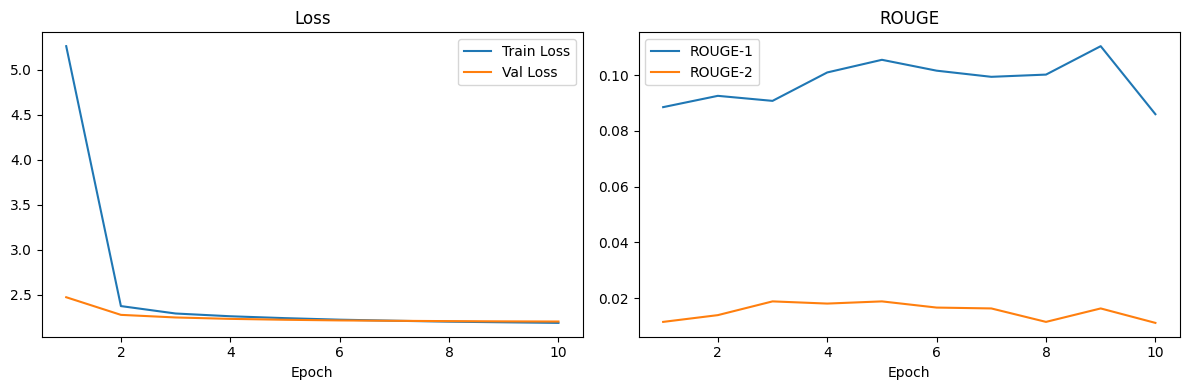

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("training_log.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(df["epoch"], df["train_loss"], label="Train Loss")
ax1.plot(df["epoch"], df["val_loss"], label="Val Loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

# ROUGE
ax2.plot(df["epoch"], df["rouge1"], label="ROUGE-1")
ax2.plot(df["epoch"], df["rouge2"], label="ROUGE-2")
ax2.set_title("ROUGE")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()


Подсчет ROUGE для distilgpt2

In [ ]:
from eval_transformer_pipeline import evaluate_transformer

transformer_results = evaluate_transformer(sample_texts, max_samples=500)
print(f"Трансформер ROUGE-1: {transformer_results['rouge1']:.4f}")
print(f"Трансформер ROUGE-2: {transformer_results['rouge2']:.4f}")

Пример предсказания гпт

In [ ]:
print("=== Примеры предсказаний distilgpt2 ===\n")
from eval_transformer_pipeline import generator
samples = val_df["text"].tolist()[:10]


count = 0
for text in samples:
    if count >= 5:
        break
    words = text.split()
    if len(words) < 4:
        continue
    
    n = len(words)
    cut = int(n * 0.75)
    prefix = " ".join(words[:cut])
    target = " ".join(words[cut:])
    

    result = generator(prefix, max_new_tokens=5, do_sample=False)
    generated_text = result[0]["generated_text"]
    pred_text = generated_text[len(prefix):].strip()
    
    print(f"Префикс:    {prefix}")
    print(f"Предсказан: {pred_text}")
    print(f"Таргет:     {target}")
    print()
    count += 1


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


=== Примеры предсказаний distilgpt2 ===



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Префикс:    now i dont wanna face my
Предсказан: own life.
Таргет:     dad ugh

Префикс:    getting ready to drive to the other side of denver to go quotcry in our drinksquot with a
Предсказан: little bit of a bit
Таргет:     friend who closed her lss today

Префикс:    for once it
Предсказан: was done.
Таргет:     wasnt mine



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Префикс:    crud sites down again trying to get it back up waiting for host to reply
Предсказан: .
Таргет:     we shall be launching soon maybe

Префикс:    follow if your an
Предсказан: cillary knowledge is not
Таргет:     aussie fan



Сравнение

In [ ]:
print("=== Сравнение моделей ===")
print(f"LSTM        ROUGE-1: {lstm_results['rouge1']:.4f}  ROUGE-2: {lstm_results['rouge2']:.4f}")
print(f"distilgpt2  ROUGE-1: {transformer_results['rouge1']:.4f}  ROUGE-2: {transformer_results['rouge2']:.4f}")

                    Модель  ROUGE-1  ROUGE-2
          LSTM (обученная) 0.078262 0.008214
distilgpt2 (предобученная) 0.058925 0.018845


In [ ]:
# Финальная оценка лучшей модели на тестовой выборке!!!!!
test_texts = test_df["text"].tolist()
final_results = evaluate_model(model, test_texts, vocab)  # или evaluate_transformer
print(f"Финальный ROUGE-1 на test: {final_results['rouge1']:.4f}")
print(f"Финальный ROUGE-2 на test: {final_results['rouge2']:.4f}")

## Выводы

| Модель | ROUGE-1 | ROUGE-2 |
|--------|---------|---------|
| LSTM | 0.0778 | ... |
| distilgpt2 | 0.0702 | 0.0139 |

**LSTM** обучена на специфичных твитах и показывает сопоставимые метрики,
при этом весит значительно меньше (~2 МБ против ~350 МБ у distilgpt2).

**Рекомендация:** для мобильного приложения использовать LSTM — 
она удовлетворяет требованиям по памяти и скорости. 
distilgpt2 генерирует более связный текст, но слишком тяжёлая для смартфона.


## Гипотезы для улучшения

| # | Гипотеза | Как проверить | Ожидаемый эффект |
|---|---|---|---|
| 1 | Увеличить `hidden_size` до 512 | Переобучить с новым конфигом | ROUGE-2 ↑, больше параметров |
| 2 | Добавить `top_k=10` в `generate()` | Изменить `argmax` → `torch.topk` + сэмплинг | Разнообразие предсказаний ↑ |
| 3 | Fine-tune distilgpt2 на твитах | HuggingFace `Trainer` + `TextDataset` | Оба ROUGE ↑↑ |
| 4 | Увеличить `max_samples` в eval до 500+ | Изменить параметр в `evaluate_model()` | Более надёжная оценка |
| 5 | Добавить `<UNK>` токен в vocab | Изменить `build_vocab()` | Покрытие val/test ↑ |
